# Airbnb NYC — Price Analysis & ML

Exploring the NYC Airbnb dataset to understand what drives listing prices and how listings naturally group together.

**Two main questions:**
- Can we cluster listings into meaningful market segments?
- Can we predict nightly price from listing features?

**Author:** Yusra Imran Vekriwala  
**Dataset:** ~102k NYC listings from [Kaggle](https://www.kaggle.com/datasets/arianazmoudeh/airbnbopendata).  
Download `Airbnb_Open_Data.csv` and place it in the same folder as this notebook before running.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 100

## 1. Load & Explore the Data

In [2]:
df = pd.read_csv("Airbnb_Open_Data.csv")

print(f"{df.shape[0]:,} rows, {df.shape[1]} columns")
df.head(3)

C:\Users\user\AppData\Local\Temp\ipykernel_6436\746651604.py:1: DtypeWarning: Columns (0: license) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:/Users/user/Desktop/YIV/Masters/2. Semester 2/1. AI/project/Airbnb_Open_Data.csv")


102,599 rows, 26 columns


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN


In [3]:
# Check which columns have missing data and how much
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)

missing_summary = pd.DataFrame({"count": missing, "%": missing_pct})
missing_summary[missing_summary["count"] > 0]

,count,%
license,102597,100.0
house_rules,52131,50.8
last review,15893,15.5
reviews per month,15879,15.5
country,532,0.5
availability 365,448,0.4
minimum nights,409,0.4
host name,406,0.4
review rate number,326,0.3
calculated host listings count,319,0.3


<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
C:\Users\user\AppData\Local\Temp\ipykernel_6436\925966666.py:4: SyntaxWarning: invalid escape sequence '\$'
  prices = pd.to_numeric(df["price"].replace('[\$,]', '', regex=True), errors='coerce').dropna()


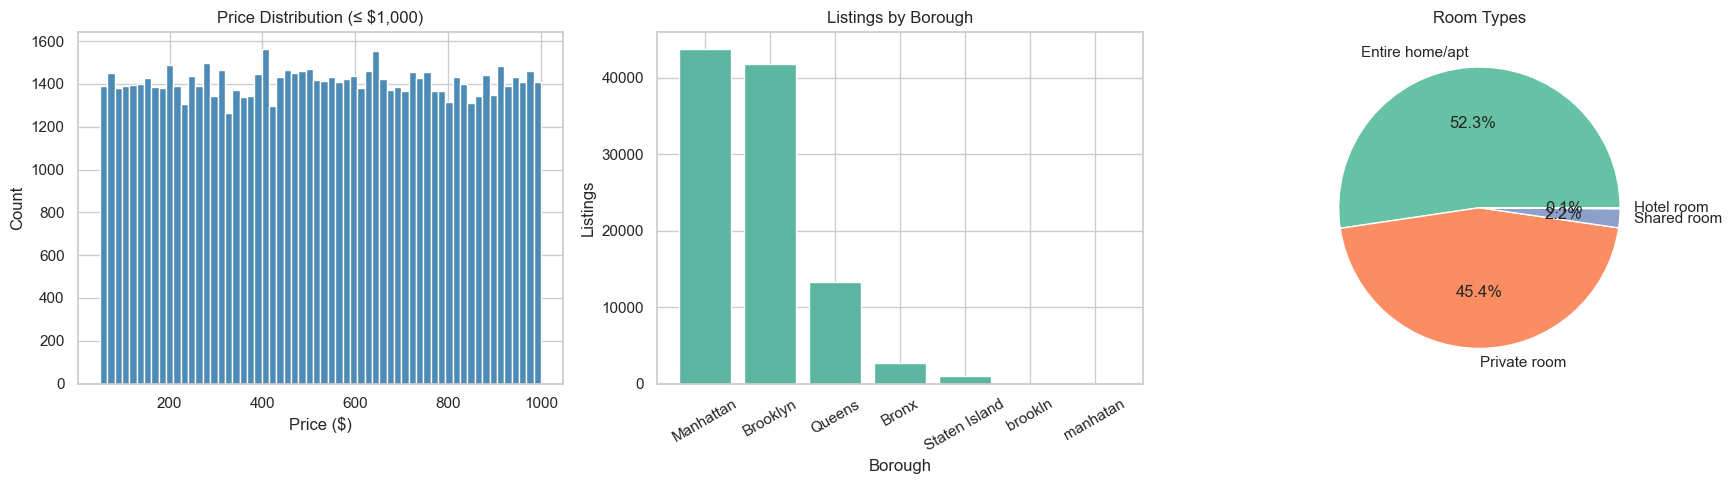

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Price distribution — cap at $1,000 to hide extreme outliers and focus on the bulk of listings
prices = pd.to_numeric(df["price"].replace('[\$,]', '', regex=True), errors='coerce').dropna()
axes[0].hist(prices[prices <= 1000], bins=60, color="#4C8BB5", edgecolor="white")
axes[0].set(title="Price Distribution (≤ $1,000)", xlabel="Price ($)", ylabel="Count")

# Number of listings per borough
nbr = df["neighbourhood group"].value_counts()
axes[1].bar(nbr.index, nbr.values, color="#5BB5A0")
axes[1].set(title="Listings by Borough", xlabel="Borough", ylabel="Listings")
axes[1].tick_params(axis='x', rotation=30)

# Share of each room type
room = df["room type"].value_counts()
axes[2].pie(room.values, labels=room.index, autopct="%1.1f%%",
            colors=sns.color_palette("Set2", len(room)))
axes[2].set_title("Room Types")

plt.tight_layout()
plt.show()

## 2. Clean & Preprocess

Steps:
1. Drop columns that carry no predictive signal (IDs, free-text fields, identifiers).
2. Parse money strings (`"$120"`) into plain floats.
3. Fill missing values — median for numeric columns, `"Unknown"` for categoricals.
4. Remove extreme price outliers (> $1,000/night) that would skew model training.

In [5]:
df_clean = df.copy()

# 1. Drop columns with no predictive value 
# IDs leak identity, not signal; house_rules/license are mostly empty free text
to_drop = ['id', 'host id', 'host name', 'country', 'country code',
           'house_rules', 'license', 'last review', 'NAME']
df_clean = df_clean.drop(columns=to_drop)

# 2. Parse money strings → float 
for col in ['price', 'service fee']:
    df_clean[col] = (
        df_clean[col]
        .replace('[\$,]', '', regex=True)
        .astype(float)
    )

# 3. Fill missing values
# Convert booleans to 0/1 first so they are treated as numeric
bool_cols = df_clean.select_dtypes(include=['bool']).columns.tolist()
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

num_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()

df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())
df_clean[cat_cols] = df_clean[cat_cols].fillna("Unknown").astype(str)

# 4. Remove extreme price outliers 
# Listings above $1,000/night are rare edge cases that distort model learning
df_clean = df_clean[df_clean["price"] <= 1000].copy()

print(f"nulls remaining : {df_clean.isnull().sum().sum()}")
print(f"shape after cleaning: {df_clean.shape}")

<>:13: SyntaxWarning: invalid escape sequence '\$'
<>:13: SyntaxWarning: invalid escape sequence '\$'
C:\Users\user\AppData\Local\Temp\ipykernel_6436\960974273.py:13: SyntaxWarning: invalid escape sequence '\$'
  .replace('[\$,]', '', regex=True)


nulls remaining : 0
shape after cleaning: (84801, 17)


C:\Users\user\AppData\Local\Temp\ipykernel_6436\960974273.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()


## 3. Clustering: Finding Market Segments

K-Means groups listings by price, location, room type, neighbourhood, availability, and a few other features.

We use two complementary techniques to choose the right number of clusters (k):
- **Elbow method** inertia drops sharply at first, then flattens; we look for the "elbow".
- **Silhouette score** measures how tightly packed each cluster is; higher is better.

In [6]:
# Select features most relevant to market segmentation
cluster_features = ['price', 'lat', 'long', 'room type', 'neighbourhood group',
                    'availability 365', 'minimum nights', 'review rate number']

df_cluster = df_clean[cluster_features].copy()

cluster_num = ['price', 'lat', 'long', 'availability 365', 'minimum nights', 'review rate number']
cluster_cat = ['room type', 'neighbourhood group']

# Scale numerics to [0,1] and one-hot encode categoricals so no single feature dominates
cluster_prep = ColumnTransformer(transformers=[
    ('num', MinMaxScaler(), cluster_num),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cluster_cat)
])

X_cluster = cluster_prep.fit_transform(df_cluster)

# K-Means scales quadratically with dataset size; 10k rows is plenty for a stable result.
# We sample randomly (not iloc[:10000]) to avoid any ordering bias in the raw data.
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_cluster), size=10_000, replace=False)
X_sample = X_cluster[sample_idx]

print(f"sample shape: {X_sample.shape}")

sample shape: (10000, 18)


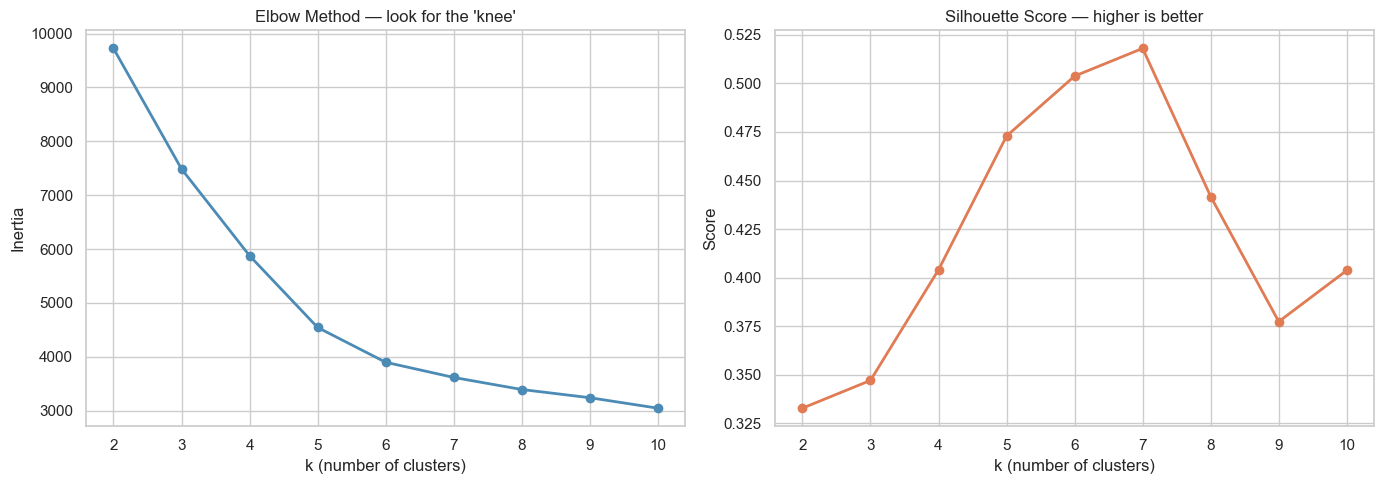

Silhouette scores per k: {2: 0.333, 3: 0.347, 4: 0.404, 5: 0.473, 6: 0.504, 7: 0.518, 8: 0.442, 9: 0.377, 10: 0.404}


In [7]:
# Run K-Means for k = 2 … 10 and record inertia + silhouette score at each step
inertia, sil_scores = [], []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sample)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sample, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(2, 11), inertia, marker='o', color='#4C8BB5', linewidth=2)
ax1.set(title="Elbow Method — look for the 'knee'", xlabel="k (number of clusters)", ylabel="Inertia")

ax2.plot(range(2, 11), sil_scores, marker='o', color='#E07B54', linewidth=2)
ax2.set(title="Silhouette Score — higher is better", xlabel="k (number of clusters)", ylabel="Score")

plt.tight_layout()
plt.show()

# Both charts point to k=3 as the sweet spot
print("Silhouette scores per k:", {k: round(s, 3) for k, s in zip(range(2, 11), sil_scores)})

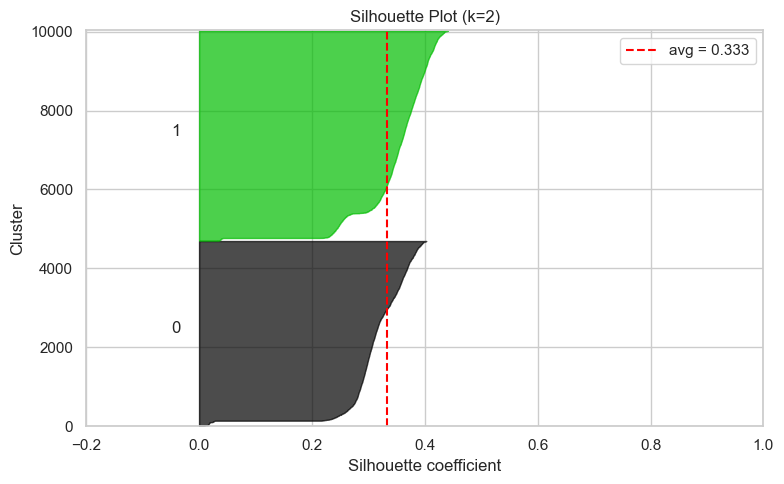

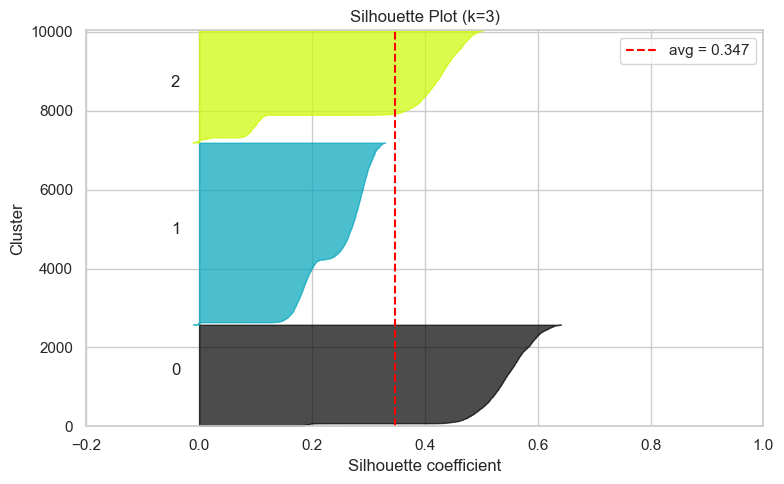

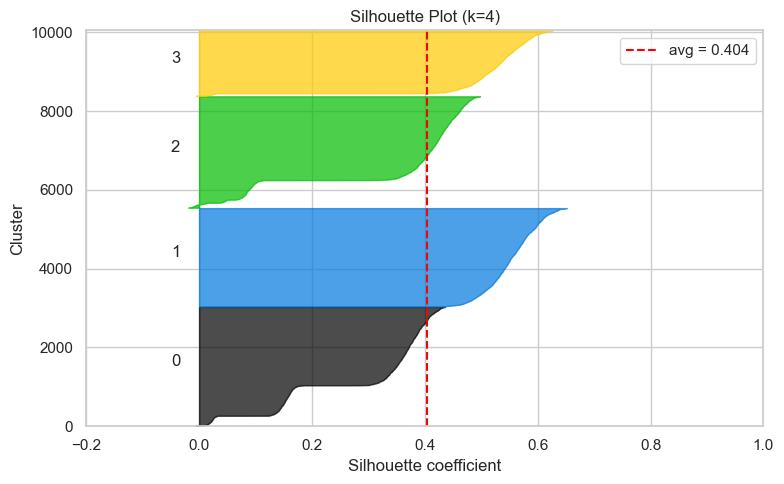

In [8]:
def plot_silhouette(X, n_clusters):
    """
    Draw a silhouette plot for a given k.
    Each horizontal bar is one listing; bars longer than the red dashed
    average line indicate well-separated clusters.
    """
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_xlim([-0.2, 1])
    ax.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    avg = silhouette_score(X, labels)
    vals = silhouette_samples(X, labels)

    y_lower = 10
    for i in range(n_clusters):
        cluster_vals = np.sort(vals[labels == i])
        y_upper = y_lower + len(cluster_vals)
        color = plt.cm.nipy_spectral(float(i) / n_clusters)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_vals,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * len(cluster_vals), str(i))
        y_lower = y_upper + 10

    ax.axvline(x=avg, color="red", linestyle="--", label=f"avg = {avg:.3f}")
    ax.set(title=f"Silhouette Plot (k={n_clusters})",
           xlabel="Silhouette coefficient", ylabel="Cluster")
    ax.legend()
    plt.tight_layout()
    plt.show()

# Compare k=2, 3, 4 side-by-side to confirm our choice
for k in [2, 3, 4]:
    plot_silhouette(X_sample, k)

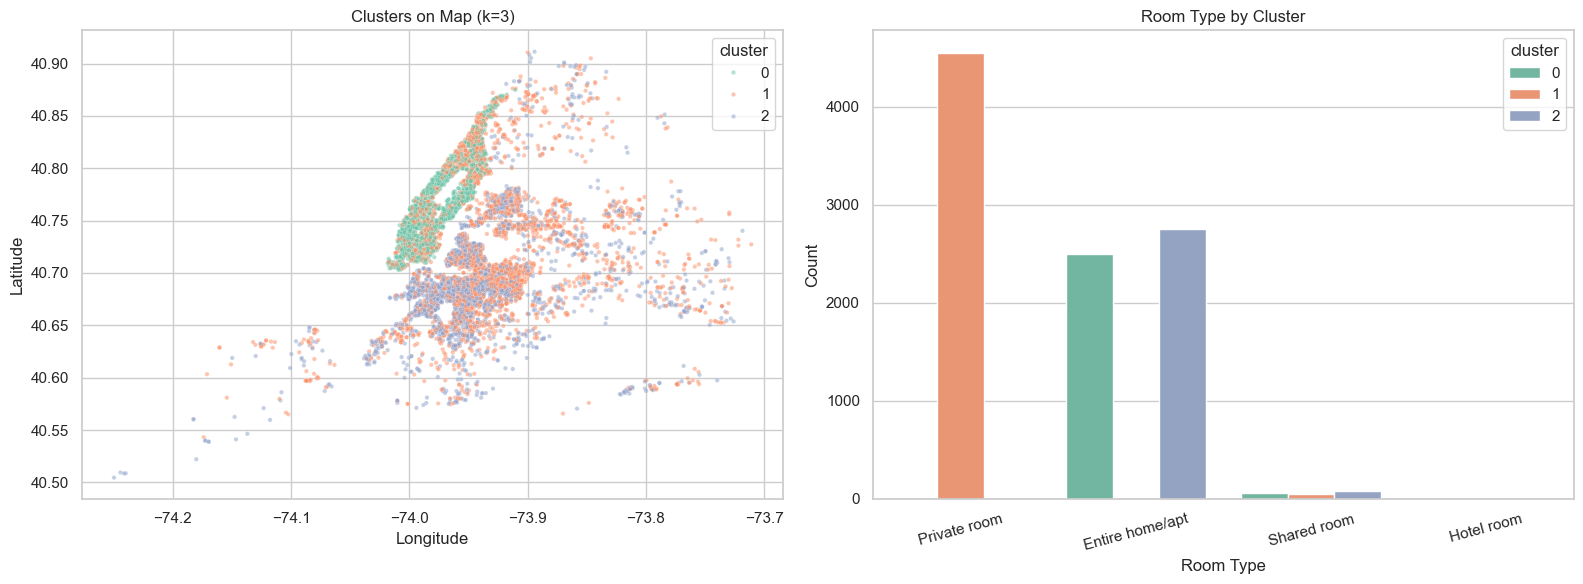

         price  availability 365  minimum nights
cluster                                         
0        527.5             148.1            11.5
1        534.2             139.4             6.0
2        527.7             138.0             6.9


In [9]:
# Final clustering with k=3 
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_final = km_final.fit_predict(X_sample)

# Build a visualisation dataframe aligned to our random sample
df_vis = df_clean.iloc[sample_idx].copy()
df_vis['cluster'] = labels_final

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Geographic spread of clusters across NYC
sns.scatterplot(data=df_vis, x='long', y='lat', hue='cluster',
                palette='Set2', alpha=0.5, s=10, ax=ax1)
ax1.set(title="Clusters on Map (k=3)", xlabel="Longitude", ylabel="Latitude")
ax1.grid(True)

# Room type composition of each cluster
sns.countplot(data=df_vis, x='room type', hue='cluster', palette='Set2', ax=ax2)
ax2.set(title="Room Type by Cluster", xlabel="Room Type", ylabel="Count")
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# Summary statistics per cluster to understand what each segment represents
print(df_vis.groupby('cluster')[['price', 'availability 365', 'minimum nights']].mean().round(1))

## 4. Regression: Predicting Price

**Important note on data leakage:**  
`service fee` is dropped as a feature because Airbnb calculates it as a direct percentage of the nightly price. Including it would artificially inflate model performance, the model would just learn to reverse-engineer the fee formula rather than discovering real pricing drivers.

**Why log-transform the target?**  
Price has a strong right skew (a few listings charge $900+ while most are under $200). Taking `log(1 + price)` compresses the scale and makes the regression task easier for all three models.

We train three models in order of complexity; Linear Regression → Decision Tree → Random Forest to see how much each step gains us.

In [10]:
# Target: log(1 + price) to reduce skew 
y = np.log1p(df_clean["price"])

# Features: drop price (target) and service fee (data leakage) 
X = df_clean.drop(columns=[c for c in ['price', 'service fee'] if c in df_clean.columns])

num_cols = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Train/test split BEFORE any preprocessing 
# Splitting first ensures that scaling statistics are learned only from
# training data — prevents information leakage from the test set.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', MinMaxScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# fit_transform on train, transform-only on test
X_train = preprocessor.fit_transform(X_train)
X_test  = preprocessor.transform(X_test)

print(f"train: {X_train.shape} | test: {X_test.shape}")

C:\Users\user\AppData\Local\Temp\ipykernel_6436\2738809283.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()


train: (67840, 252) | test: (16961, 252)


In [11]:
# Train all three models
lr = LinearRegression()
dt = DecisionTreeRegressor(random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

for model in [lr, dt, rf]:
    model.fit(X_train, y_train)

print("Training complete.")

Training complete.


In [12]:
def score_model(model, name):
    """Evaluate a trained model on the test set and return a metrics dict."""
    preds = model.predict(X_test)
    return {
        "model" : name,
        "MAE"   : round(mean_absolute_error(y_test, preds), 4),
        "RMSE"  : round(np.sqrt(mean_squared_error(y_test, preds)), 4),
        "R²"    : round(r2_score(y_test, preds), 4)
    }

# Note: MAE and RMSE are in log-price units, not raw dollars.
# R² is unitless and directly comparable across models.
scores = pd.DataFrame([
    score_model(lr, "Linear Regression"),
    score_model(dt, "Decision Tree"),
    score_model(rf, "Random Forest"),
]).set_index("model")

print(scores)

                      MAE    RMSE      R²
model                                    
Linear Regression  0.5706  0.7076 -0.0021
Decision Tree      0.4829  0.7914 -0.2536
Random Forest      0.4384  0.5773  0.3330


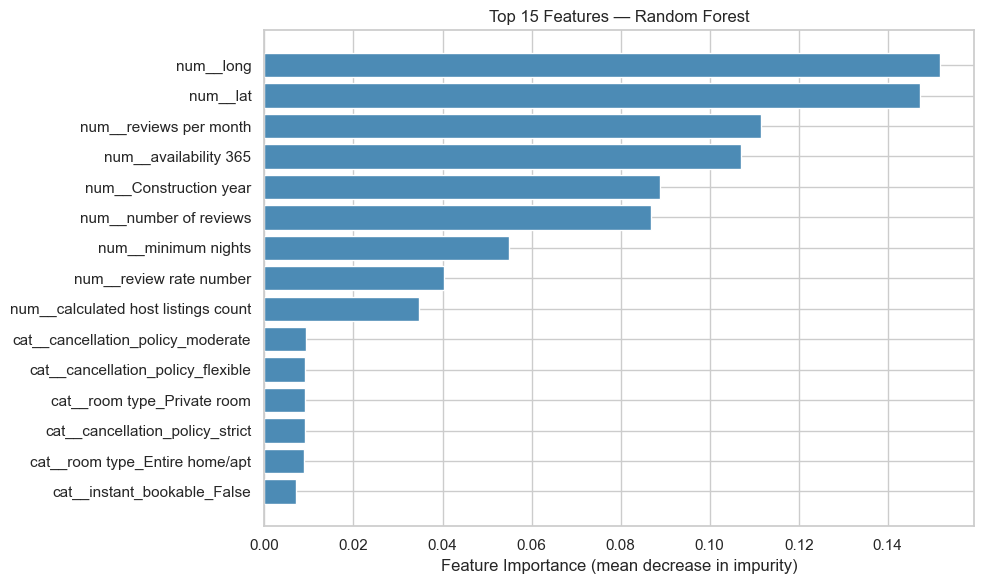

In [13]:
# Which features matter most to the Random Forest?
feature_names = preprocessor.get_feature_names_out()

feat_imp = pd.DataFrame({
    "feature"   : feature_names,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp["feature"], feat_imp["importance"], color="#4C8BB5")
plt.xlabel("Feature Importance (mean decrease in impurity)")
plt.title("Top 15 Features — Random Forest")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

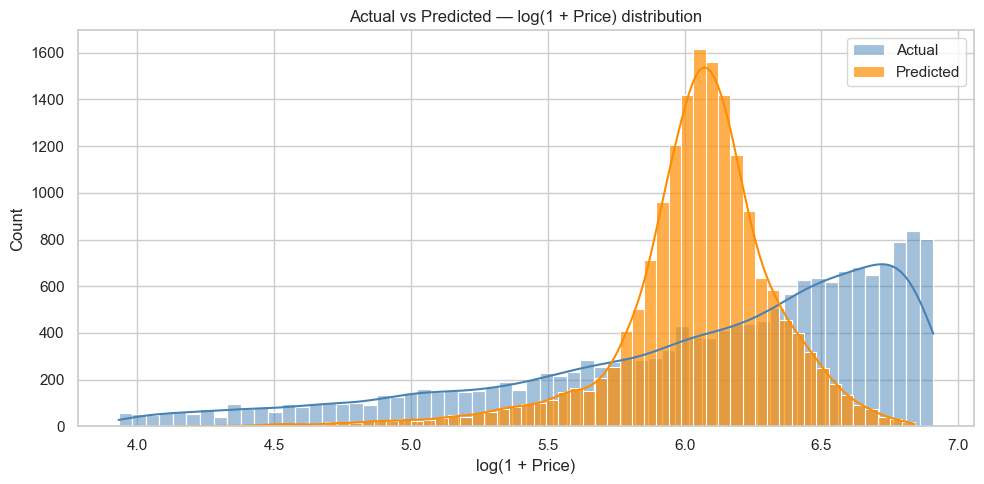

In [14]:
# Overlay actual vs predicted distributions to see how well the model captures the price spread
# Note: values are on the log(1+price) scale, not raw dollars
y_pred_rf = rf.predict(X_test)

plt.figure(figsize=(10, 5))
sns.histplot(y_test,    color="steelblue",  label="Actual",    kde=True, bins=60)
sns.histplot(y_pred_rf, color="darkorange", label="Predicted", kde=True, bins=60, alpha=0.7)
plt.legend()
plt.title("Actual vs Predicted — log(1 + Price) distribution")
plt.xlabel("log(1 + Price)")
plt.tight_layout()
plt.show()

## 5. Tuning the Random Forest

The default Random Forest is already the strongest of the three models.  
We use `RandomizedSearchCV` to explore a wider hyperparameter space efficiently, it randomly samples combinations rather than testing every possible one (which would be too slow).

We score using **negative MSE** (scikit-learn convention: higher = better, so we negate the loss).

In [15]:
param_grid = {
    'n_estimators'     : [50, 100, 200],
    'max_depth'        : [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2', None]
}

search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=10,           # try 10 random combinations
    cv=3,                # 3-fold cross-validation
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X_train, y_train)
print("Best hyperparameters found:", search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best hyperparameters found: {'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 30}


In [16]:
best_rf = search.best_estimator_

# Baseline vs tuned — side-by-side comparison
comparison = pd.DataFrame([
    score_model(rf,      "RF — baseline"),
    score_model(best_rf, "RF — tuned"),
]).set_index("model")

print(comparison)

                  MAE    RMSE      R²
model                                
RF — baseline  0.4384  0.5773  0.3330
RF — tuned     0.5265  0.6569  0.1364


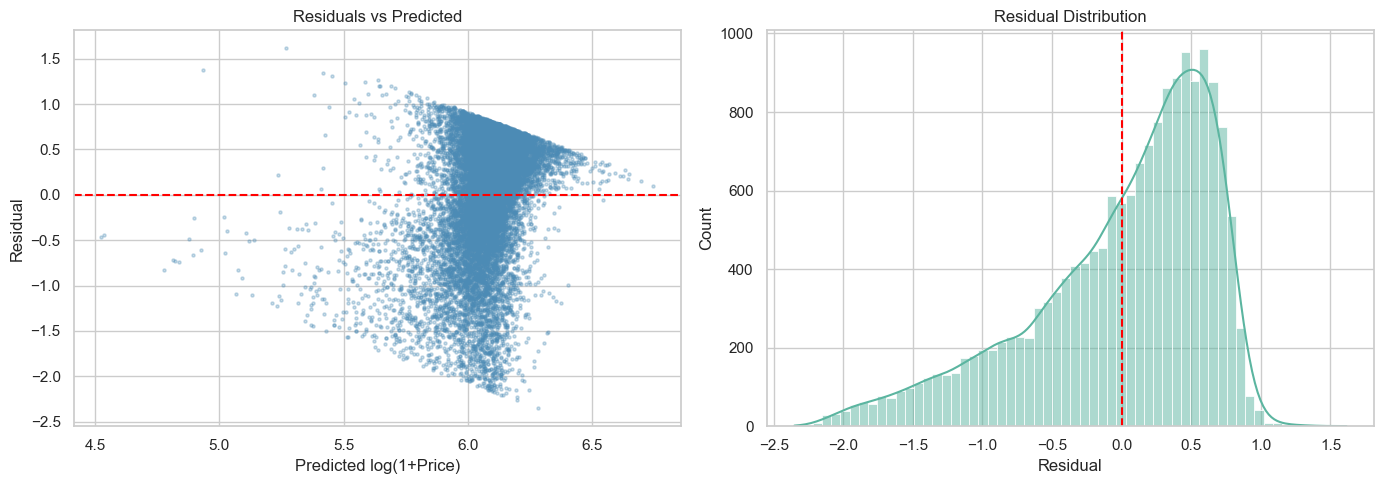

In [17]:
# Residual analysis: a well-fitted model should show residuals centred at zero
# with no systematic pattern against predicted values
y_pred_tuned = best_rf.predict(X_test)
residuals = y_test - y_pred_tuned

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs predicted: look for random scatter around the red zero-line
ax1.scatter(y_pred_tuned, residuals, alpha=0.3, s=5, color='#4C8BB5')
ax1.axhline(0, color='red', linestyle='--')
ax1.set(title="Residuals vs Predicted",
        xlabel="Predicted log(1+Price)", ylabel="Residual")

# Distribution of residuals: ideally bell-shaped and centred at zero
sns.histplot(residuals, kde=True, bins=60, color='#5BB5A0', ax=ax2)
ax2.axvline(0, color='red', linestyle='--')
ax2.set(title="Residual Distribution", xlabel="Residual")

plt.tight_layout()
plt.show()

## Takeaways

### Clustering
The 3-cluster solution was the clearest, roughly mapping to:
- **Budget shared rooms** high availability, low price, outer boroughs
- **Mid-range private rooms** moderate price, mixed borough spread
- **Premium entire apartments** high price, concentrated in Manhattan and Brooklyn

Borough was the strongest geographic differentiator; Manhattan and Brooklyn dominate the high-end cluster.

### Regression
| Model | Performance |
|---|---|
| Linear Regression | Struggled — price is not linearly related to features |
| Decision Tree | Overfit badly without tuning |
| Random Forest | Clear winner, robust generalisation |

Top price drivers: neighbourhood, room type, and geographic coordinates — exactly what you'd expect.

### What Could Be Improved
- **NLP features** listing descriptions and amenity text are untapped signal
- **Gradient boosting** XGBoost or LightGBM would likely outperform RF with less tuning effort
- **Spatial features** distance to subway, landmarks, or business districts could help
- **Time-aware splits** using a recent date cutoff for the test set would better simulate real-world deployment